In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [4]:
df = pd.read_csv("students.csv")
df.head()


,Student_id,Age,Program,Semester,GPA,Attendance,Assignments_completion,Stress_level,Sleep_hours,Mental_wellbeing,...,Distractions,Carreer_clarity,Skill_readiness,Engagement_score,APS,WWS,PTMS,CRS,SRI,Category
0,S210,20,BCA,5,7.16,65,50,7,5,4,...,7,4,6,68,65.30,42.75,41.4,50.0,50.990,Yellow
1,S211,21,MBA,3,8.05,88,79,4,7,7,...,2,8,7,62,82.45,71.25,61.6,75.0,73.135,Blue
2,S212,22,BBA,5,6.25,62,55,8,4,2,...,8,2,3,75,60.85,29.00,26.5,25.0,36.930,Red
3,S213,19,BSC,2,5.01,53,33,2,7,8,...,5,7,7,81,47.55,82.25,65.3,70.0,64.540,Yellow
4,S214,23,BA,4,6.35,60,22,6,5,9,...,5,4,5,60,54.15,61.75,66.0,45.0,56.345,Yellow


In [5]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.head()


,Age,Semester,GPA,Attendance,Assignments_completion,Stress_level,Sleep_hours,Mental_wellbeing,Productivity_score,Distractions,Carreer_clarity,Skill_readiness,Engagement_score,APS,WWS,PTMS,CRS,SRI
0,20,5,7.16,65,50,7,5,4,6,7,4,6,68,65.30,42.75,41.4,50.0,50.990
1,21,3,8.05,88,79,4,7,7,7,2,8,7,62,82.45,71.25,61.6,75.0,73.135
2,22,5,6.25,62,55,8,4,2,4,8,2,3,75,60.85,29.00,26.5,25.0,36.930
3,19,2,5.01,53,33,2,7,8,8,5,7,7,81,47.55,82.25,65.3,70.0,64.540
4,23,4,6.35,60,22,6,5,9,9,5,4,5,60,54.15,61.75,66.0,45.0,56.345


In [6]:
df_numeric = df_numeric.fillna(df_numeric.mean())


In [7]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)


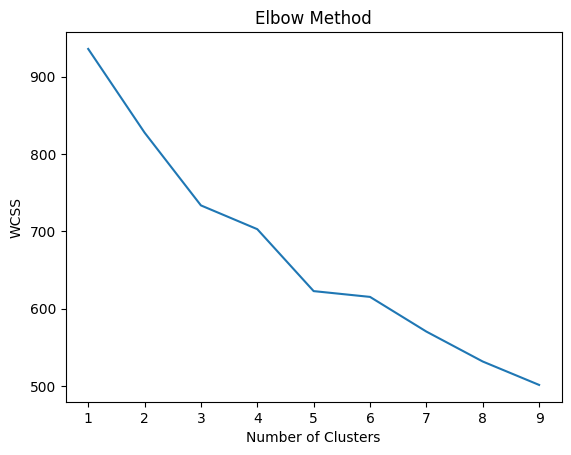

In [8]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters
df.head()


,Student_id,Age,Program,Semester,GPA,Attendance,Assignments_completion,Stress_level,Sleep_hours,Mental_wellbeing,...,Carreer_clarity,Skill_readiness,Engagement_score,APS,WWS,PTMS,CRS,SRI,Category,Cluster
0,S210,20,BCA,5,7.16,65,50,7,5,4,...,4,6,68,65.30,42.75,41.4,50.0,50.990,Yellow,1
1,S211,21,MBA,3,8.05,88,79,4,7,7,...,8,7,62,82.45,71.25,61.6,75.0,73.135,Blue,2
2,S212,22,BBA,5,6.25,62,55,8,4,2,...,2,3,75,60.85,29.00,26.5,25.0,36.930,Red,1
3,S213,19,BSC,2,5.01,53,33,2,7,8,...,7,7,81,47.55,82.25,65.3,70.0,64.540,Yellow,1
4,S214,23,BA,4,6.35,60,22,6,5,9,...,4,5,60,54.15,61.75,66.0,45.0,56.345,Yellow,1


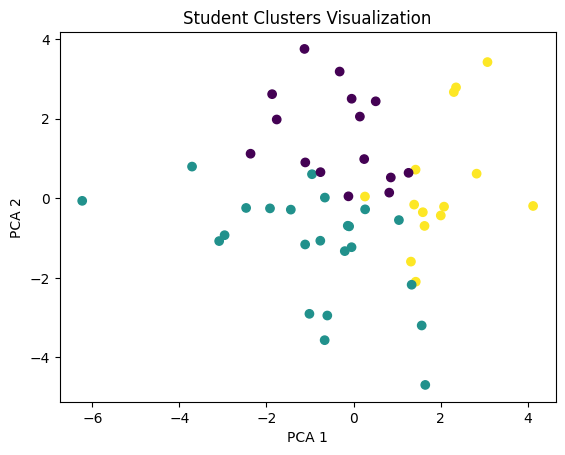

In [10]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Student Clusters Visualization")
plt.show()


In [16]:
df.groupby("Cluster").mean(numeric_only=True)


,Age,Semester,GPA,Attendance,Assignments_completion,Stress_level,Sleep_hours,Mental_wellbeing,Productivity_score,Distractions,Carreer_clarity,Skill_readiness,Engagement_score,APS,WWS,PTMS,CRS,SRI
Cluster,,,,,,,,,,,,,,,,,,
0,22.466667,4.400000,7.809333,68.866667,68.266667,6.00000,6.000000,6.666667,4.333333,7.800000,6.866667,6.866667,66.000000,73.360000,58.250000,26.733333,68.666667,57.5080
1,21.478261,3.826087,6.421739,59.130435,62.434783,6.26087,6.521739,5.782609,6.608696,6.086957,5.652174,5.130435,59.826087,62.334783,56.271739,45.947826,53.913043,54.9200
2,22.285714,4.071429,8.162143,77.785714,68.357143,7.50000,7.642857,6.285714,7.571429,5.428571,6.571429,6.285714,73.142857,77.817857,56.982143,58.657143,64.285714,65.4775


In [18]:
print(df.columns)


Index(['Student_id', 'Age', 'Program', 'Semester', 'GPA', 'Attendance',
       'Assignments_completion', 'Stress_level', 'Sleep_hours',
       'Mental_wellbeing', 'Productivity_score', 'Distractions',
       'Carreer_clarity', 'Skill_readiness', 'Engagement_score', 'APS', 'WWS',
       'PTMS', 'CRS', 'SRI', 'Category', 'Cluster'],
      dtype='str')


In [23]:
pd.crosstab(df["Cluster"], df["SRI"])


SRI,36.930,45.590,46.625,48.190,50.225,50.305,50.990,51.430,52.165,53.645,...,63.995,64.540,65.205,65.425,65.430,65.670,68.100,69.820,70.080,73.135
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,0,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,1,1,1,1,1,1
